In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
file_path = "weather.csv"
weather_data = pd.read_csv(file_path)

In [4]:

# Task 1: Add Date and Month columns, calculate monthly average temperatures
weather_data['Date'] = pd.date_range(start='1/1/2024', periods=len(weather_data), freq='D')
weather_data['Month'] = weather_data['Date'].dt.month

monthly_avg_temp = weather_data.groupby('Month')[['MinTemp', 'MaxTemp']].mean()
monthly_avg_temp['AvgTemp'] = (monthly_avg_temp['MinTemp'] + monthly_avg_temp['MaxTemp']) / 2

print("Monthly Average Temperatures:")
print(monthly_avg_temp)

Monthly Average Temperatures:
         MinTemp    MaxTemp    AvgTemp
Month                                 
1      11.861290  24.903226  18.382258
2      13.234483  24.993103  19.113793
3      15.225806  29.309677  22.267742
4      12.863333  24.680000  18.771667
5      10.867742  25.987097  18.427419
6       5.183333  19.500000  12.341667
7       2.538710  17.232258   9.885484
8       4.441935  14.445161   9.443548
9      -0.263333  11.690000   5.713333
10      0.329032  12.841935   6.585484
11      3.860000  18.013333  10.936667
12      7.190323  23.025806  15.108065


In [5]:
# Task 2: Identify regions with most precipitation
windgust_precip = weather_data.groupby('WindGustDir')['Rainfall'].sum()
winddir9am_precip = weather_data.groupby('WindDir9am')['Rainfall'].sum()
winddir3pm_precip = weather_data.groupby('WindDir3pm')['Rainfall'].sum()

most_precip_gust = windgust_precip.idxmax(), windgust_precip.max()
most_precip_9am = winddir9am_precip.idxmax(), winddir9am_precip.max()
most_precip_3pm = winddir3pm_precip.idxmax(), winddir3pm_precip.max()

print("Wind Gust Direction with most precipitation:", most_precip_gust)
print("Wind Direction at 9am with most precipitation:", most_precip_9am)
print("Wind Direction at 3pm with most precipitation:", most_precip_3pm)



Wind Gust Direction with most precipitation: ('NW', 152.2)
Wind Direction at 9am with most precipitation: ('NNW', 77.0)
Wind Direction at 3pm with most precipitation: ('W', 88.2)


C:\Users\User\AppData\Local\Temp\ipykernel_8204\783873442.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['AvgTemp'] = (filtered_data['MinTemp'] + filtered_data['MaxTemp']) / 2


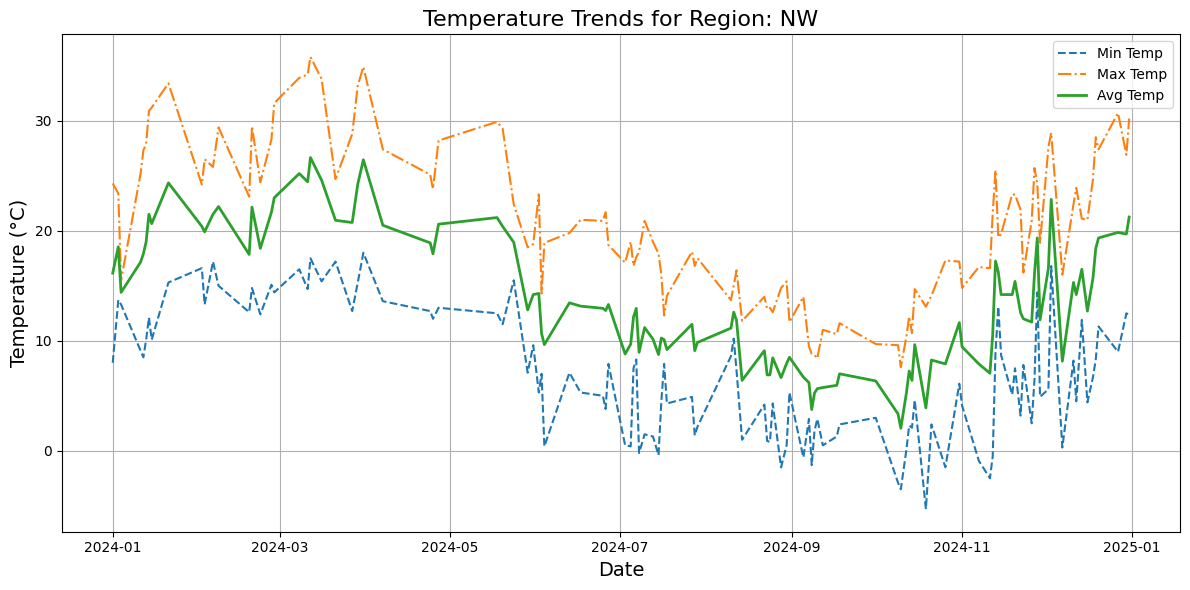

In [6]:
# Task 3: Plot temperature trends for a selected region
selected_region = 'NW'
filtered_data = weather_data[(weather_data['WindGustDir'] == selected_region) |
                     (weather_data['WindDir9am'] == selected_region) |
                     (weather_data['WindDir3pm'] == selected_region)]


filtered_data['AvgTemp'] = (filtered_data['MinTemp'] + filtered_data['MaxTemp']) / 2

plt.figure(figsize=(12, 6))
plt.plot(filtered_data['Date'], filtered_data['MinTemp'], label='Min Temp', linestyle='--')
plt.plot(filtered_data['Date'], filtered_data['MaxTemp'], label='Max Temp', linestyle='-.')
plt.plot(filtered_data['Date'], filtered_data['AvgTemp'], label='Avg Temp', linewidth=2)

plt.title(f"Temperature Trends for Region: {selected_region}", fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


Correlation Matrix:
                AvgTemp  WindSpeed9am  WindSpeed3pm  WindGustSpeed  Rainfall
AvgTemp        1.000000     -0.057354     -0.127702       0.171961  0.060869
WindSpeed9am  -0.057354      1.000000      0.472966       0.527653  0.219637
WindSpeed3pm  -0.127702      0.472966      1.000000       0.693945  0.056008
WindGustSpeed  0.171961      0.527653      0.693945       1.000000  0.096190
Rainfall       0.060869      0.219637      0.056008       0.096190  1.000000


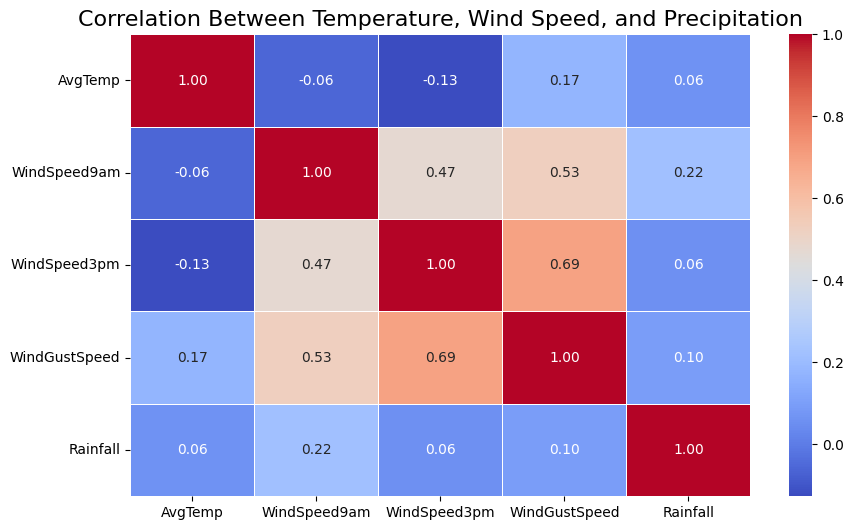

In [7]:
# Task 4: Correlation analysis between temperature, wind speed, and precipitation
weather_data['AvgTemp'] = (weather_data['MinTemp'] + weather_data['MaxTemp']) / 2
correlation_data = weather_data[['AvgTemp', 'WindSpeed9am', 'WindSpeed3pm', 'WindGustSpeed', 'Rainfall']]
correlation_matrix = correlation_data.corr()
print("Correlation Matrix:")
print(correlation_matrix)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Temperature, Wind Speed, and Precipitation', fontsize=16)
plt.show()


In [8]:
# Task 5: Find the day with the most stable temperature in each region
weather_data['TempVariation'] = weather_data['MaxTemp'] - weather_data['MinTemp']
region_column = 'WindGustDir'  
most_stable_temp_day = weather_data.loc[weather_data.groupby(region_column)['TempVariation'].idxmin()]
most_stable_temp_day_result = most_stable_temp_day[['Date', 'TempVariation', region_column, 'MinTemp', 'MaxTemp']]
print(most_stable_temp_day_result)


          Date  TempVariation WindGustDir  MinTemp  MaxTemp
21  2024-01-22            3.0           E     16.4     19.4
95  2024-04-05            4.4         ENE     18.2     22.6
215 2024-08-03            4.6         ESE      9.8     14.4
281 2024-10-08            9.4           N      3.1     12.5
79  2024-03-20            4.3          NE     15.3     19.6
221 2024-08-09            8.9         NNE      7.4     16.3
51  2024-02-21            2.1         NNW     19.9     22.0
3   2024-01-04            2.2          NW     13.3     15.5
45  2024-02-15            5.6           S     15.5     21.1
141 2024-05-21            1.8          SE     13.0     14.8
119 2024-04-29            2.5         SSE     14.8     17.3
98  2024-04-08            9.7         SSW     14.5     24.2
36  2024-02-06            8.6          SW     17.2     25.8
232 2024-08-20            3.3           W      8.4     11.7
225 2024-08-13            4.3         WNW      8.7     13.0
87  2024-03-28           18.1         WS